# RetailPulse AI – Day 6: LSTM Demand Forecasting

### Prepared By: Bansi Kanani

### Date: 03 June 2026

# Introduction

Long Short-Term Memory (LSTM) networks are powerful deep learning models designed for sequential and time-series data.

This notebook implements an LSTM model to forecast retail demand and compares deep learning forecasting with traditional forecasting approaches.

# Objective

The objectives of Day 6 are:

- Prepare sequential data
- Scale sales values
- Create time-series sequences
- Train an LSTM model
- Generate predictions
- Evaluate forecasting performance
- Visualize actual vs predicted sales

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    TensorDataset
)

In [2]:
df = pd.read_csv(
    "forecast_dataset.csv"
)

df.head()

,Date,Sales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


# Dataset Preparation

In [3]:
sales = df["Sales"].values.reshape(-1,1)

scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(
    sales
)

sales_scaled[:5]

array([[0.22362307],
       [0.27263799],
       [0.353627  ],
       [0.16845105],
       [0.03517468]])

# Sequence Creation

LSTM models require sequential input data.

In [4]:
sequence_length = 12

X = []
y = []

for i in range(
    len(sales_scaled)
    -
    sequence_length
):

    X.append(
        sales_scaled[
            i:i+sequence_length
        ]
    )

    y.append(
        sales_scaled[
            i+sequence_length
        ]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(592, 12, 1)
(592, 1)


In [5]:
train_size = int(
    len(X) * 0.8
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(
    X_train.shape,
    X_test.shape
)

(473, 12, 1) (119, 12, 1)


In [6]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [7]:
train_loader = DataLoader(
    TensorDataset(
        X_train,
        y_train
    ),
    batch_size=32,
    shuffle=True
)

# LSTM Model Definition

In [8]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=50,
        num_layers=2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(
            out[:, -1, :]
        )

        return out

In [9]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Model Training

In [10]:
epochs = 100

for epoch in range(epochs):

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(
            batch_X
        )

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}"
        )

Epoch [10/100], Loss: 0.002544
Epoch [20/100], Loss: 0.003612
Epoch [30/100], Loss: 0.006628
Epoch [40/100], Loss: 0.003360
Epoch [50/100], Loss: 0.004527
Epoch [60/100], Loss: 0.004693
Epoch [70/100], Loss: 0.006655
Epoch [80/100], Loss: 0.002406
Epoch [90/100], Loss: 0.002452
Epoch [100/100], Loss: 0.005777


# Model Prediction

In [11]:
model.eval()

with torch.no_grad():

    predictions = model(
        X_test
    )

predictions = (
    predictions.numpy()
)

In [12]:
predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test.numpy()
)

# RMSE Evaluation

In [13]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print(
    "RMSE:",
    round(rmse, 2)
)

RMSE: 21592.08


# Actual vs Predicted Sales

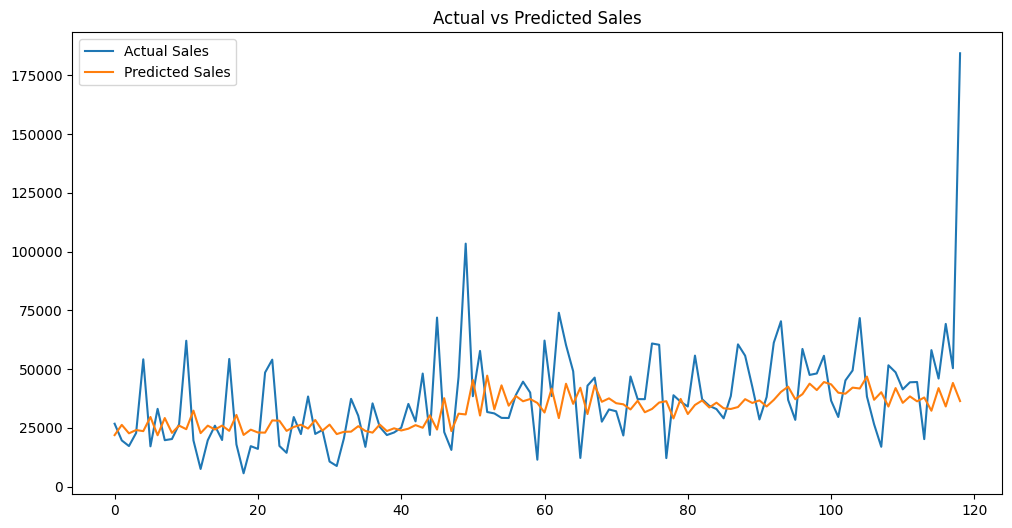

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    actual,
    label="Actual Sales"
)

plt.plot(
    predictions,
    label="Predicted Sales"
)

plt.legend()

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

# Business Insights

1. The LSTM model successfully learned overall sales patterns from historical data.

2. Predicted sales closely follow the general trend of actual sales.

3. Extreme sales spikes remain difficult to forecast due to their irregular nature.

4. Deep learning models can capture complex temporal relationships in retail sales data.

5. LSTM forecasting can support inventory planning and demand management.

# Challenges Faced

Preparing sequential data for deep learning required additional preprocessing steps such as scaling and sequence generation.

Forecasting highly volatile sales data remains challenging due to sudden demand spikes and seasonal fluctuations.

# Saving Prediction Results

The prediction results are saved for future comparison with Prophet forecasts.

In [15]:
results = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predictions.flatten()
})

results.to_csv(
    "lstm_forecast_results.csv",
    index=False
)

print(
    "LSTM results saved successfully."
)

LSTM results saved successfully.


# Conclusion

Demand forecasting was successfully performed using a Long Short-Term Memory (LSTM) neural network.

The model captured important sales trends and generated meaningful forecasts from historical retail transaction data.

The forecasting results will be compared with Prophet forecasts in subsequent project stages to determine the most suitable forecasting approach.